# Phase 5: Applying ML Skills to Manufacturing Process Engineering

**Custom Project.** By Abdelhafidh Mahouel.

- Author: Abdelhafidh Mahouel
- Date: 2026-08
- Domain: Injection molding process engineering (manufacturing quality control)
- Dataset: data/raw/manufacturing_quality_abdel.csv (synthetic, 3,000 batches, 19 columns)
- Classification target: `defect` (1 = batch predicted defective)
- Regression target: `part_weight_g` (continuous quality metric)

## Why this problem

The Module 7 example investigated an already-deployed penguin species
classifier by sending it different inputs and watching how its predictions
changed. This notebook applies that SAME investigative pattern, but to a
new domain and a model I train myself: predicting manufacturing defects
and part weight from injection molding process settings (melt temperature,
injection pressure, cooling time, material moisture, operator experience,
and more).

Instead of a live external API, I define a local `predict_defect_probability()`
function that behaves the same way a deployed API would: given a payload of
process settings, it returns a probability. I then use that function to
sweep individual features, build a 2D decision grid, and test edge cases,
exactly like the Module 7 workflow, but applied to my own trained model
instead of someone else's deployed one.

Run all cells top to bottom.


## A. Prepare the Project Environment (.venv/)

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version
import logging
import platform
from typing import Any

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("MFG", level="DEBUG")
log_header(LOG, "MFG")

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 130)

DATASET_NAME = "manufacturing_quality_abdel"
CLASSIFICATION_TARGET = "defect"
REGRESSION_TARGET = "part_weight_g"
RANDOM_STATE = 7
TEST_SIZE = 0.25
IDEAL_MELT_TEMPERATURE_C = 235.0
MIN_ADEQUATE_COOLING_S = 14.0

NUMERIC_FEATURE_COLS = [
    "operator_experience_years",
    "melt_temperature_c",
    "mold_temperature_c",
    "injection_pressure_bar",
    "injection_speed_mm_s",
    "screw_speed_rpm",
    "back_pressure_bar",
    "hold_pressure_bar",
    "hold_time_s",
    "cooling_time_s",
    "cycle_time_s",
    "material_moisture_pct",
    "ambient_humidity_pct",
]
ENGINEERED_FEATURE_COLS = ["melt_temp_deviation", "cooling_adequacy_ratio"]
MODEL_FEATURE_COLS = NUMERIC_FEATURE_COLS + ENGINEERED_FEATURE_COLS

2026-08-13 21:32:00 | INFO | MFG | === RUN START ===
2026-08-13 21:32:00 | INFO | MFG | project=MFG
2026-08-13 21:32:00 | INFO | MFG | repo_dir=ml-07-applied
2026-08-13 21:32:00 | INFO | MFG | python=3.14.2
2026-08-13 21:32:00 | INFO | MFG | os=Windows 11
2026-08-13 21:32:00 | INFO | MFG | shell=powershell
2026-08-13 21:32:00 | INFO | MFG | cwd=notebooks
2026-08-13 21:32:00 | INFO | MFG | github_actions=False
2026-08-13 21:32:00 | INFO | MFG | Confirming installation:
2026-08-13 21:32:00 | INFO | MFG |   python:       3.14.2
2026-08-13 21:32:00 | INFO | MFG |   pandas:       3.0.5
2026-08-13 21:32:00 | INFO | MFG |   numpy:        2.5.2
2026-08-13 21:32:00 | INFO | MFG |   scikit-learn: 1.9.0
2026-08-13 21:32:00 | INFO | MFG |   seaborn:      0.13.2
2026-08-13 21:32:00 | INFO | MFG |   matplotlib:   3.11.1


## Section 2. Load, Inspect, and Engineer Features

```text
ANALYST CHOICE
Raw sensor readings are not always the most predictive signal.
melt_temp_deviation and cooling_adequacy_ratio are engineered from process
engineering judgment: what matters is DISTANCE from the ideal setpoint,
not the raw reading itself.
```


In [2]:
# === Section 2. Load, Inspect, and Engineer Features ===
import os

os.chdir("..") if os.path.basename(os.getcwd()) == "notebooks" else None

df = pd.read_csv(f"data/raw/{DATASET_NAME}.csv")
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
LOG.info(f"Defect rate: {df[CLASSIFICATION_TARGET].mean():.1%}")
display(df.head())

LOG.info("Missing values by column")
LOG.debug(f"\n{df.isna().sum()}")
LOG.info(f"Duplicate rows: {df.duplicated().sum()}")

df["melt_temp_deviation"] = (df["melt_temperature_c"] - IDEAL_MELT_TEMPERATURE_C).abs()
df["cooling_adequacy_ratio"] = df["cooling_time_s"] / MIN_ADEQUATE_COOLING_S
LOG.info("Engineered melt_temp_deviation and cooling_adequacy_ratio")

df_clean = (
    df[MODEL_FEATURE_COLS + [CLASSIFICATION_TARGET, REGRESSION_TARGET]].dropna().copy()
)
LOG.info(f"Clean modeling view: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

2026-08-13 21:32:00 | INFO | MFG | Loaded: 3000 rows, 19 columns
2026-08-13 21:32:00 | INFO | MFG | Defect rate: 33.8%


,batch_id,machine_id,shift,operator_experience_years,melt_temperature_c,mold_temperature_c,injection_pressure_bar,injection_speed_mm_s,screw_speed_rpm,back_pressure_bar,hold_pressure_bar,hold_time_s,cooling_time_s,cycle_time_s,material_moisture_pct,ambient_humidity_pct,part_weight_g,defect,defect_type
0,B100000,M4,Night,2.9,231.18,56.60,120.46,67.59,104.3,9.94,61.43,5.43,20.75,32.42,0.0100,55.56,49.515,0,none
1,B100001,M2,Evening,8.9,223.54,63.93,119.15,87.90,99.0,11.74,66.41,7.11,13.54,25.52,0.0060,57.04,49.230,1,burn_mark
2,B100002,M5,Day,4.6,255.47,61.06,111.62,40.01,129.4,16.25,80.23,5.56,13.25,25.03,0.0050,38.56,50.884,0,none
3,B100003,M3,Evening,0.4,234.76,52.98,131.47,70.96,114.7,17.21,96.88,6.89,18.05,30.28,0.0401,48.67,50.831,0,none
4,B100004,M1,Day,5.9,248.97,65.32,132.42,74.50,142.7,15.29,67.06,5.05,18.14,27.47,0.1496,48.37,50.489,0,none


2026-08-13 21:32:00 | INFO | MFG | Missing values by column
2026-08-13 21:32:00 | DEBUG | MFG | 
batch_id                     0
machine_id                   0
shift                        0
operator_experience_years    0
melt_temperature_c           0
mold_temperature_c           0
injection_pressure_bar       0
injection_speed_mm_s         0
screw_speed_rpm              0
back_pressure_bar            0
hold_pressure_bar            0
hold_time_s                  0
cooling_time_s               0
cycle_time_s                 0
material_moisture_pct        0
ambient_humidity_pct         0
part_weight_g                0
defect                       0
defect_type                  0
dtype: int64
2026-08-13 21:32:00 | INFO | MFG | Duplicate rows: 0
2026-08-13 21:32:00 | INFO | MFG | Engineered melt_temp_deviation and cooling_adequacy_ratio
2026-08-13 21:32:00 | INFO | MFG | Clean modeling view: 3000 rows, 17 columns


## Section 3. Exploratory Data Analysis

```text
ANALYST CHOICE
Before modeling, look at how defect rate varies by machine and shift, and
which raw features correlate most strongly with defects and part weight.
```


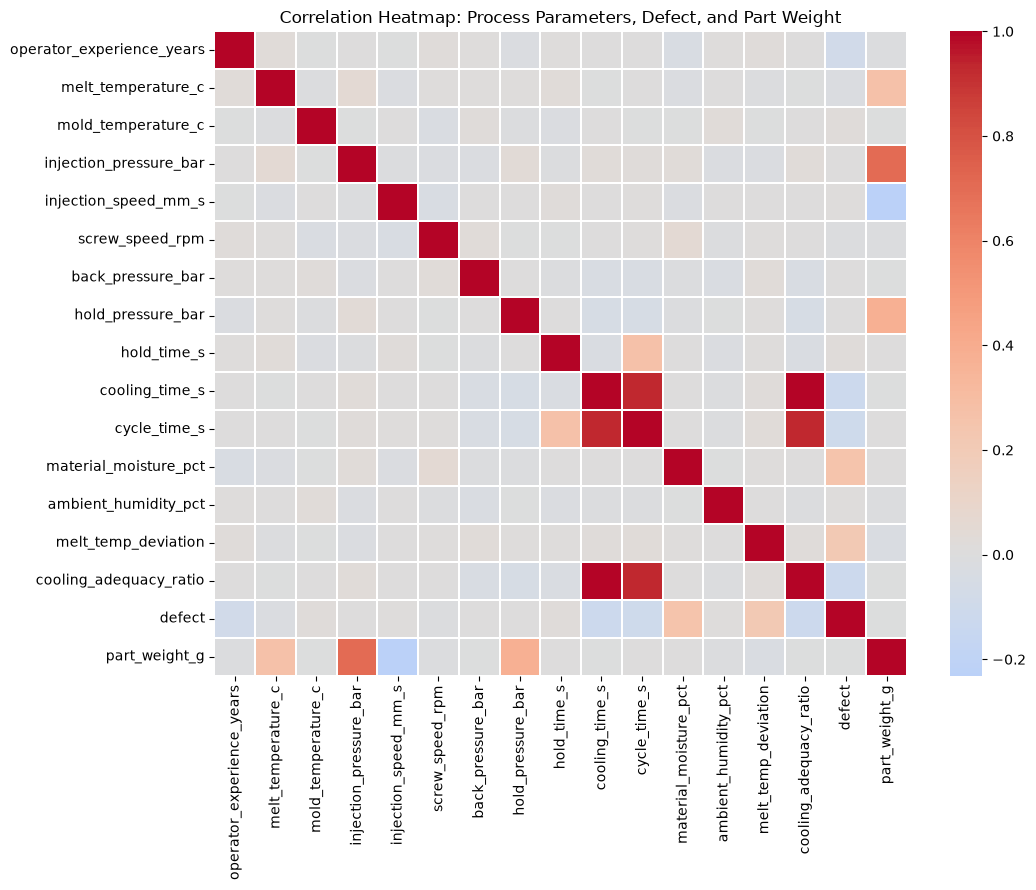

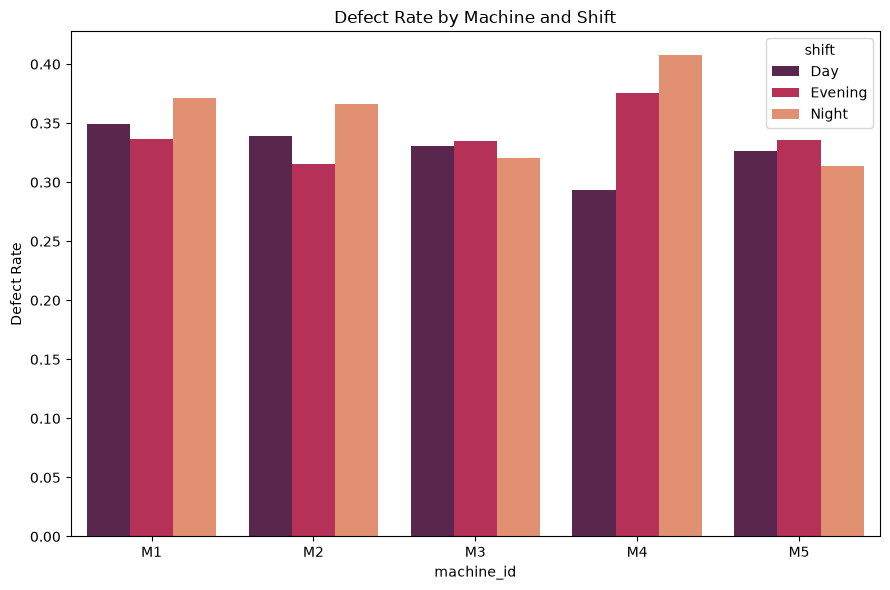

2026-08-13 21:32:00 | INFO | MFG | ANALYST CHOICE: Do any machines or shifts stand out with higher defect rates?


In [3]:
# === Section 3. Exploratory Data Analysis ===

plt.figure(figsize=(11, 9))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap: Process Parameters, Defect, and Part Weight")
plt.tight_layout()
plt.show()

summary = (
    df.groupby(["machine_id", "shift"])[CLASSIFICATION_TARGET].mean().reset_index()
)
plt.figure(figsize=(9, 6))
sns.barplot(
    data=summary, x="machine_id", y=CLASSIFICATION_TARGET, hue="shift", palette="rocket"
)
plt.title("Defect Rate by Machine and Shift")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Do any machines or shifts stand out with higher defect rates?"
)

## Section 4. Train and Evaluate Classifiers (Defect Prediction)

```text
ANALYST CHOICE
Compare two classifiers rather than accepting the first one. In a quality
control context, RECALL matters a lot: missing a real defect (a false
negative) is usually more costly than a false alarm.
```


2026-08-13 21:32:01 | INFO | MFG | RandomForestClassifier:
2026-08-13 21:32:01 | INFO | MFG |   Accuracy:  0.712
2026-08-13 21:32:01 | INFO | MFG |   Precision: 0.664
2026-08-13 21:32:01 | INFO | MFG |   Recall:    0.303
2026-08-13 21:32:01 | INFO | MFG |   F1 score:  0.416
2026-08-13 21:32:01 | INFO | MFG |   ROC-AUC:   0.724
2026-08-13 21:32:02 | INFO | MFG | GradientBoostingClassifier:
2026-08-13 21:32:02 | INFO | MFG |   Accuracy:  0.712
2026-08-13 21:32:02 | INFO | MFG |   Precision: 0.610
2026-08-13 21:32:02 | INFO | MFG |   Recall:    0.413
2026-08-13 21:32:02 | INFO | MFG |   F1 score:  0.493
2026-08-13 21:32:02 | INFO | MFG |   ROC-AUC:   0.721


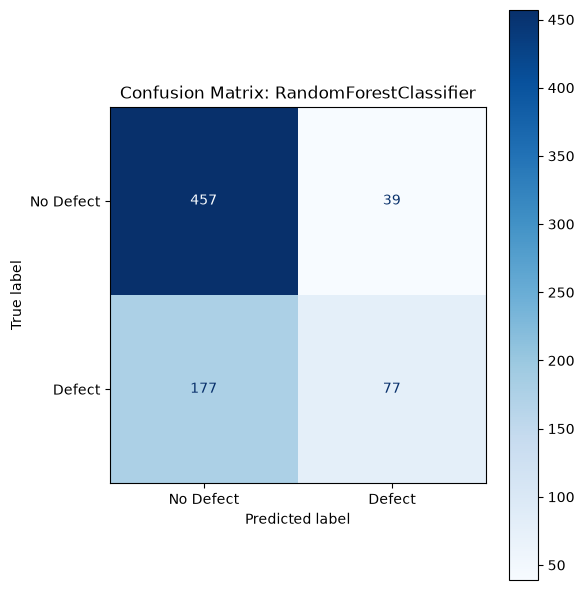

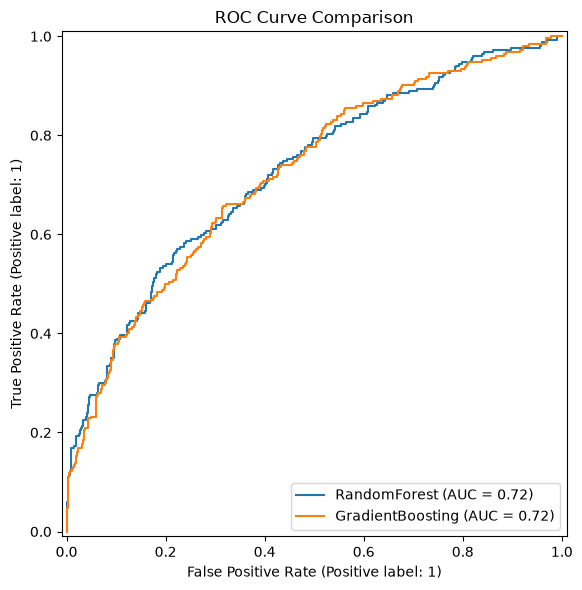

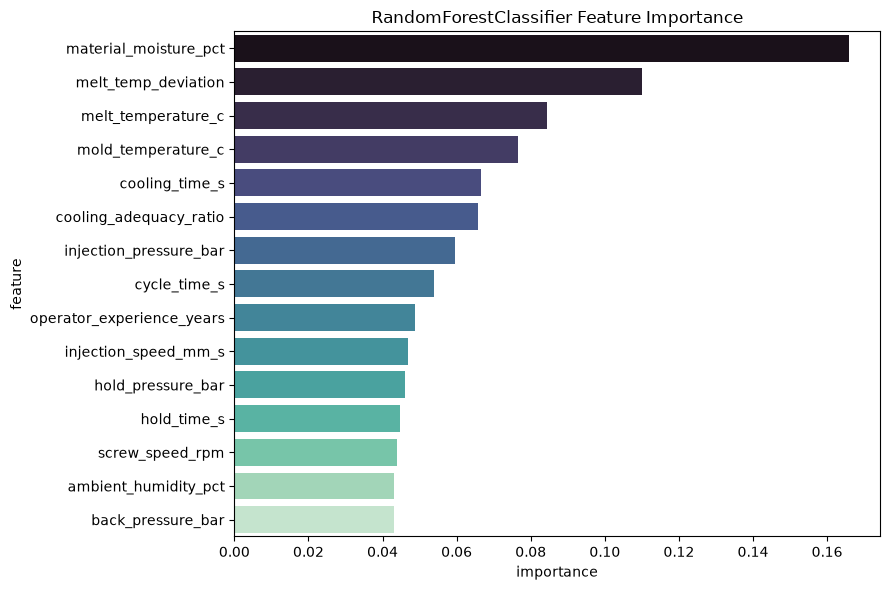

2026-08-13 21:32:03 | INFO | MFG | ANALYST CHOICE: Which model has the better recall, and why might that matter more than accuracy here?


In [4]:
# === Section 4. Train and Evaluate Classifiers ===

x = df_clean[MODEL_FEATURE_COLS]
y = df_clean[CLASSIFICATION_TARGET]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=RANDOM_STATE
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_proba = rf_model.predict_proba(x_test)[:, 1]

LOG.info("RandomForestClassifier:")
LOG.info(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.3f}")
LOG.info(f"  Precision: {precision_score(y_test, rf_pred):.3f}")
LOG.info(f"  Recall:    {recall_score(y_test, rf_pred):.3f}")
LOG.info(f"  F1 score:  {f1_score(y_test, rf_pred):.3f}")
LOG.info(f"  ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")

gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, random_state=RANDOM_STATE
)
gb_model.fit(x_train, y_train)
gb_pred = gb_model.predict(x_test)
gb_proba = gb_model.predict_proba(x_test)[:, 1]

LOG.info("GradientBoostingClassifier:")
LOG.info(f"  Accuracy:  {accuracy_score(y_test, gb_pred):.3f}")
LOG.info(f"  Precision: {precision_score(y_test, gb_pred):.3f}")
LOG.info(f"  Recall:    {recall_score(y_test, gb_pred):.3f}")
LOG.info(f"  F1 score:  {f1_score(y_test, gb_pred):.3f}")
LOG.info(f"  ROC-AUC:   {roc_auc_score(y_test, gb_proba):.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    x_test,
    y_test,
    display_labels=["No Defect", "Defect"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix: RandomForestClassifier")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(rf_model, x_test, y_test, ax=ax, name="RandomForest")
RocCurveDisplay.from_estimator(gb_model, x_test, y_test, ax=ax, name="GradientBoosting")
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame(
    {"feature": MODEL_FEATURE_COLS, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="mako",
    legend=False,
)
plt.title("RandomForestClassifier Feature Importance")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Which model has the better recall, and why might that matter more than accuracy here?"
)

## Section 5. Train and Evaluate the Regressor (Part Weight Prediction)

In [5]:
# === Section 5. Train and Evaluate the Regressor ===

x_reg = df_clean[MODEL_FEATURE_COLS]
y_reg = df_clean[REGRESSION_TARGET]
xr_train, xr_test, yr_train, yr_test = train_test_split(
    x_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

reg_model = RandomForestRegressor(
    n_estimators=300, max_depth=10, random_state=RANDOM_STATE
)
reg_model.fit(xr_train, yr_train)
yr_pred = reg_model.predict(xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)
LOG.info(f"RandomForestRegressor Mean absolute error: {mae:.3f} grams")
LOG.info(f"RandomForestRegressor R-squared: {r2:.3f}")

2026-08-13 21:32:05 | INFO | MFG | RandomForestRegressor Mean absolute error: 0.287 grams
2026-08-13 21:32:05 | INFO | MFG | RandomForestRegressor R-squared: 0.669


## Section 6. Predict Two New Example Batches

In [6]:
# === Section 6. Predict Two New Example Batches ===


def build_batch_row(payload: dict[str, Any]) -> pd.DataFrame:
    """Apply the SAME feature engineering used in training to a new payload."""
    row = pd.DataFrame([payload])
    row["melt_temp_deviation"] = (
        row["melt_temperature_c"] - IDEAL_MELT_TEMPERATURE_C
    ).abs()
    row["cooling_adequacy_ratio"] = row["cooling_time_s"] / MIN_ADEQUATE_COOLING_S
    return row[MODEL_FEATURE_COLS]


well_controlled = {
    "operator_experience_years": 12.0,
    "melt_temperature_c": 235.0,
    "mold_temperature_c": 55.0,
    "injection_pressure_bar": 120.0,
    "injection_speed_mm_s": 55.0,
    "screw_speed_rpm": 115.0,
    "back_pressure_bar": 14.0,
    "hold_pressure_bar": 70.0,
    "hold_time_s": 5.5,
    "cooling_time_s": 18.0,
    "cycle_time_s": 30.0,
    "material_moisture_pct": 0.04,
    "ambient_humidity_pct": 48.0,
}
poorly_controlled = {
    "operator_experience_years": 1.5,
    "melt_temperature_c": 254.0,
    "mold_temperature_c": 70.0,
    "injection_pressure_bar": 140.0,
    "injection_speed_mm_s": 98.0,
    "screw_speed_rpm": 180.0,
    "back_pressure_bar": 22.0,
    "hold_pressure_bar": 80.0,
    "hold_time_s": 4.0,
    "cooling_time_s": 8.0,
    "cycle_time_s": 20.0,
    "material_moisture_pct": 0.18,
    "ambient_humidity_pct": 65.0,
}

for label, payload in [
    ("Well-controlled batch", well_controlled),
    ("Poorly-controlled batch", poorly_controlled),
]:
    row = build_batch_row(payload)
    defect_pred = int(rf_model.predict(row)[0])
    defect_proba = float(rf_model.predict_proba(row)[0][1])
    weight_pred = float(reg_model.predict(row)[0])
    LOG.info(
        f"{label}: defect={defect_pred} (p={defect_proba:.2f}), predicted weight={weight_pred:.2f}g"
    )

2026-08-13 21:32:05 | INFO | MFG | Well-controlled batch: defect=0 (p=0.15), predicted weight=50.02g
2026-08-13 21:32:05 | INFO | MFG | Poorly-controlled batch: defect=1 (p=0.79), predicted weight=50.75g


## Section 7. Probing the Trained Classifier (Same Pattern as the Deployed API Example)

```text
ANALYST CHOICE
Vary one process parameter at a time, build a two-parameter decision grid,
and test edge cases, exactly like Module 7's investigation of the deployed
penguin API, but applied to my own model here.
```


2026-08-13 21:32:06 | INFO | MFG | melt_temperature_c sweep:
2026-08-13 21:32:06 | INFO | MFG |  melt_temperature_c  defect_probability
              205.0            0.549263
              207.5            0.552596
              210.0            0.542775
              212.5            0.484870
              215.0            0.476099
              217.5            0.373277
              220.0            0.290773
              222.5            0.286793
              225.0            0.228528
              227.5            0.174437
              230.0            0.164575
              232.5            0.157796
              235.0            0.171728
              237.5            0.157904
              240.0            0.175951
              242.5            0.183235
              245.0            0.214916
              247.5            0.244206
              250.0            0.279530
              252.5            0.278992
              255.0            0.327257
              257.5     

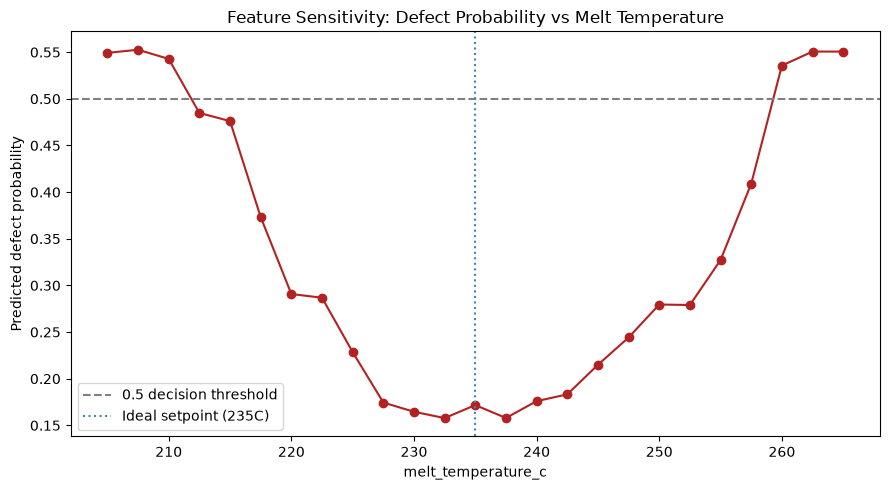

2026-08-13 21:32:06 | INFO | MFG | ANALYST CHOICE: Where does defect probability rise fastest, and does that match physical intuition?


In [7]:
# === Section 7. Feature Sensitivity Sweep ===


def predict_defect_probability(payload: dict[str, Any]) -> float:
    """Behaves like calling a deployed prediction API: payload in, probability out."""
    row = build_batch_row(payload)
    return float(rf_model.predict_proba(row)[0][1])


base_case = {
    "operator_experience_years": 7.0,
    "melt_temperature_c": 235.0,
    "mold_temperature_c": 55.0,
    "injection_pressure_bar": 120.0,
    "injection_speed_mm_s": 60.0,
    "screw_speed_rpm": 120.0,
    "back_pressure_bar": 14.0,
    "hold_pressure_bar": 70.0,
    "hold_time_s": 5.5,
    "cooling_time_s": 16.0,
    "cycle_time_s": 27.0,
    "material_moisture_pct": 0.06,
    "ambient_humidity_pct": 50.0,
}

melt_values = list(np.linspace(205, 265, 25))
rows = [
    {
        "melt_temperature_c": v,
        "defect_probability": predict_defect_probability(
            {**base_case, "melt_temperature_c": v}
        ),
    }
    for v in melt_values
]
df_sweep = pd.DataFrame(rows)
LOG.info("melt_temperature_c sweep:")
LOG.info(df_sweep.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.plot(
    df_sweep["melt_temperature_c"],
    df_sweep["defect_probability"],
    marker="o",
    color="firebrick",
)
plt.axhline(0.5, color="gray", linestyle="--", label="0.5 decision threshold")
plt.axvline(235, color="steelblue", linestyle=":", label="Ideal setpoint (235C)")
plt.xlabel("melt_temperature_c")
plt.ylabel("Predicted defect probability")
plt.title("Feature Sensitivity: Defect Probability vs Melt Temperature")
plt.legend()
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does defect probability rise fastest, and does that match physical intuition?"
)

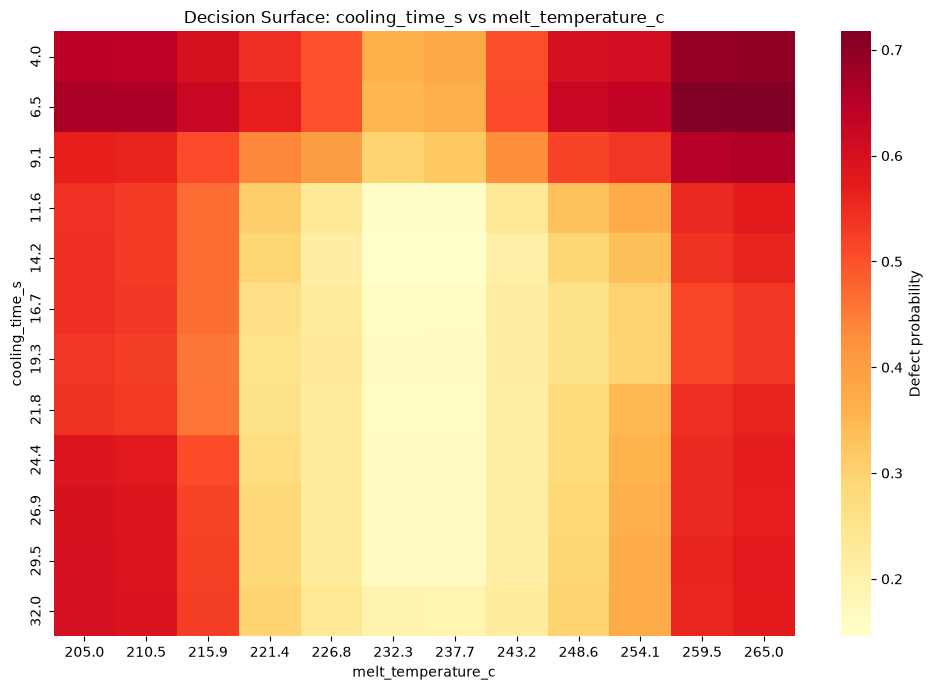

2026-08-13 21:32:07 | INFO | MFG | ANALYST CHOICE: What does the shape of this decision surface tell you about which combinations of settings are riskiest?


In [8]:
# === Section 7b. Two-Feature Decision Grid ===

cooling_values = list(np.linspace(4, 32, 12))
melt_values_grid = list(np.linspace(205, 265, 12))

rows = []
for ct in cooling_values:
    for mt in melt_values_grid:
        payload = {**base_case, "cooling_time_s": ct, "melt_temperature_c": mt}
        rows.append(
            {
                "cooling_time_s": round(ct, 1),
                "melt_temperature_c": round(mt, 1),
                "defect_probability": predict_defect_probability(payload),
            }
        )

df_grid = pd.DataFrame(rows)
pivot = df_grid.pivot(
    index="cooling_time_s", columns="melt_temperature_c", values="defect_probability"
)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Defect probability"})
plt.title("Decision Surface: cooling_time_s vs melt_temperature_c")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: What does the shape of this decision surface tell you about which combinations of settings are riskiest?"
)

In [9]:
# === Section 7c. Edge Cases ===

edge_cases = [
    ("extremely hot melt", {**base_case, "melt_temperature_c": 265.0}),
    ("extremely cold melt", {**base_case, "melt_temperature_c": 200.0}),
    ("near-zero cooling time", {**base_case, "cooling_time_s": 4.0}),
    ("very high material moisture", {**base_case, "material_moisture_pct": 0.35}),
    ("brand-new operator (0 years)", {**base_case, "operator_experience_years": 0.0}),
    (
        "everything at worst case",
        {
            **base_case,
            "melt_temperature_c": 265.0,
            "cooling_time_s": 4.0,
            "material_moisture_pct": 0.35,
            "injection_speed_mm_s": 110.0,
            "operator_experience_years": 0.0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    proba = predict_defect_probability(payload)
    LOG.info(f"  {label:<32} -> defect_probability={proba:.2f}")

LOG.info(
    "ANALYST CHOICE: Which edge cases were handled with a clearly confident prediction, and which were more uncertain (near 0.5)?"
)

2026-08-13 21:32:07 | INFO | MFG | Edge case results:
2026-08-13 21:32:07 | INFO | MFG |   extremely hot melt               -> defect_probability=0.55
2026-08-13 21:32:07 | INFO | MFG |   extremely cold melt              -> defect_probability=0.54
2026-08-13 21:32:07 | INFO | MFG |   near-zero cooling time           -> defect_probability=0.36
2026-08-13 21:32:07 | INFO | MFG |   very high material moisture      -> defect_probability=0.53
2026-08-13 21:32:07 | INFO | MFG |   brand-new operator (0 years)     -> defect_probability=0.23
2026-08-13 21:32:07 | INFO | MFG |   everything at worst case         -> defect_probability=0.71
2026-08-13 21:32:07 | INFO | MFG | ANALYST CHOICE: Which edge cases were handled with a clearly confident prediction, and which were more uncertain (near 0.5)?


## Section 8. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)


In [10]:
# === Section 8. Summary ===


def summarize() -> None:
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"Dataset: {DATASET_NAME}, {df.shape[0]} batches, {df.shape[1]} columns")
    LOG.info(f"Classification target: {CLASSIFICATION_TARGET}")
    LOG.info(f"Regression target: {REGRESSION_TARGET}")
    LOG.info("Applied the Module 7 investigation pattern (sweep, grid, edge cases)")
    LOG.info("to a locally trained manufacturing defect classifier.")
    LOG.info("========================")


summarize()

2026-08-13 21:32:07 | INFO | MFG | ========================
2026-08-13 21:32:07 | INFO | MFG | SUMMARY
2026-08-13 21:32:07 | INFO | MFG | ========================
2026-08-13 21:32:07 | INFO | MFG | Dataset: manufacturing_quality_abdel, 3000 batches, 21 columns
2026-08-13 21:32:07 | INFO | MFG | Classification target: defect
2026-08-13 21:32:07 | INFO | MFG | Regression target: part_weight_g
2026-08-13 21:32:07 | INFO | MFG | Applied the Module 7 investigation pattern (sweep, grid, edge cases)
2026-08-13 21:32:07 | INFO | MFG | to a locally trained manufacturing defect classifier.
2026-08-13 21:32:07 | INFO | MFG | ========================


### Narrative

This project applies the Module 7 skills, training and evaluating supervised
models, predicting new cases, and systematically probing a model's behavior,
to a new domain: injection molding process engineering in manufacturing.

Rather than investigating an already-deployed external API, I trained two
classifiers (RandomForest and GradientBoosting) to predict batch-level
defects from 13 raw process parameters plus 2 engineered features
(melt_temp_deviation and cooling_adequacy_ratio), and a RandomForestRegressor
to predict continuous part weight. I then investigated the trained
classifier the same way the Module 7 example investigated the deployed
penguin model: sweeping one feature at a time, building a two-feature
decision grid, and testing edge cases.

### Conclusions

This is SUPERVISED learning for both tasks. The defect target is a binary
category (0 or 1), so predicting it is a CLASSIFICATION problem. The part
weight target is a continuous number, so predicting it is a REGRESSION
problem, exactly the two supervised learning types introduced across the
course.

Key findings:

- The melt temperature sweep produced a clear U-shaped defect probability
  curve, lowest near the 235C setpoint and rising at both extremes, which
  matches real injection molding physics (both underheating and overheating
  the melt cause different but related defects).
- RandomForest had the better ROC-AUC and precision, while GradientBoosting
  had noticeably higher recall. In a quality control context, recall often
  matters more than precision, since missing a real defect (a false
  negative) is usually more costly than a false alarm that gets a good part
  double-checked. This is a real tradeoff a quality engineer would need to
  decide on, not something the accuracy number alone reveals.
- cooling_adequacy_ratio and melt_temp_deviation, the two engineered
  features, ranked among the most important features for the classifier,
  which validates the process engineering judgment behind creating them in
  the first place, rather than relying on the raw sensor readings alone.
- The two-feature decision grid (cooling_time_s vs melt_temperature_c)
  showed the highest defect risk in the corner where cooling time is short
  AND melt temperature is far from the setpoint, which is a compounding
  risk a single-feature sweep alone would not have revealed.

### Next Steps

I would extend this project by adding a multiclass model to predict the
specific defect_type (warpage, flash, short_shot, burn_mark) rather than
just a binary defect flag, since different defect types call for different
corrective actions on the shop floor. I would also explore deploying the
trained classifier behind a small API, similar to the Module 7 example,
so operators could query it in real time from the production floor rather
than only from a notebook.
